In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from pyspark.sql.functions import col, count, isnan, when
from pyspark.sql.functions import col
from pyspark.sql.functions import to_date
import math
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



Note: 
Work in Windows:
Apple stock price data was first downloaded via yfinance library (in Windows).
It was then stored as Apple1.csv (in Windows). 
EDA alongwith some statistical analysis and visualizations were carried out on this data in another jupyter notebook called stockEDA (in Windows).
The reason for carrying out this detailed analysis in Windows was the requirement of statsmodels library for some EDA steps. For carrying these steps in VM, I would have needed to create a virtual environment. In order to avoid that I have downloaded data via yfinance and done detailed EDA in Windows. However, the major work has all been carried out in VM.

Work in VM:
In VM, I have uploaded Apple1.csv file in HDFS. Then used pyspark to launch my jupyter notebook. 
Then basic EDA, Data Preparation/Preprocessing and Visualization along with Model Training of LSTM, GRU, BiLSTM and BIGRU have all been carried out in VM.
Overall, all the work presented in this notebook has been done in VM using HDFS, Pyspark and Pytorch. 


### Loading data from HDFS

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AppleStockPricenew") \
    .getOrCreate()

df = spark.read.csv("hdfs:///user1/Apple1.csv", header=True, inferSchema=True)
#show top first rows in spark dataframe
df.show(5)


+-------------------+------------------+------------------+------------------+------------------+---------+---------+------------+
|               Date|              Open|              High|               Low|             Close|   Volume|Dividends|Stock Splits|
+-------------------+------------------+------------------+------------------+------------------+---------+---------+------------+
|2021-01-04 05:00:00|130.10136410422703|130.18905617994074|123.51444475784658|126.09659576416016|143301900|      0.0|         0.0|
|2021-01-05 05:00:00|125.58986443353002|128.36689819774932|125.14163585794874|127.65557861328125| 97664900|      0.0|         0.0|
|2021-01-06 05:00:00|124.44986199518105|127.69460255545032|123.14416745080455|123.35853576660156|155088000|      0.0|         0.0|
|2021-01-07 05:00:00|125.07346559980046|128.25974454135618|124.58626762143851|127.56791687011719|109578200|      0.0|         0.0|
|2021-01-08 05:00:00| 129.0392208425577|129.23411188523488|126.89555318600054|128.6

In [5]:
#to displays the structure (schema) of the spark dataFrame — i.e., the column names, their data types,etc.
df.printSchema()

root
 |-- Date: timestamp (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)



In [6]:
#to generates summary statistics
df.describe(["Open", "High", "Low", "Close", "Volume"]).show()

25/10/19 21:06:11 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------------+------------------+--------------------+
|summary|              Open|              High|               Low|             Close|              Volume|
+-------+------------------+------------------+------------------+------------------+--------------------+
|  count|              1193|              1193|              1193|              1193|                1193|
|   mean| 174.8903601686275| 176.8090068659968|173.15167171960687|  175.075184216943| 7.109014710813077E7|
| stddev| 35.32814033529778|35.580184631885054|35.120767612359245|  35.4013750462182|2.9903919743883654E7|
|    min|116.15567868178947|117.49257992082933|113.40376109045417|113.55014038085938|            23234700|
|    max|257.27667867815336| 259.1799258751944| 256.7186620602343| 258.1037292480469|           318679900|
+-------+------------------+------------------+------------------+------------------+--------------------+



### Preprocessing/Data Preparation (in Pyspark)

In [7]:

# Separate numeric and non-numeric columns
numeric_cols = [c[0] for c in df.dtypes if c[1] in ('int', 'double')]
non_numeric_cols = [c[0] for c in df.dtypes if c[1] not in ('int', 'double')]

# Count nulls for numeric columns and check for NaN as well
numeric_nulls = df.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in numeric_cols])

# Count nulls for non-numeric columns i.e. check for NULL
non_numeric_nulls = df.select([count(when(col(c).isNull(), c)).alias(c) for c in non_numeric_cols])

# Show results
print("Numeric column nulls:")
numeric_nulls.show()
print("Non-numeric column nulls:")
non_numeric_nulls.show()


Numeric column nulls:
+----+----+---+-----+------+---------+------------+
|Open|High|Low|Close|Volume|Dividends|Stock Splits|
+----+----+---+-----+------+---------+------------+
|   0|   0|  0|    0|     0|        0|           0|
+----+----+---+-----+------+---------+------------+

Non-numeric column nulls:
+----+
|Date|
+----+
|   0|
+----+



This shows the the spark dataframe has no null values.

In [8]:

# Select useful columns (indirectly dropping Dividends and Stock Split columns as they contain zero values)
#df_clean = df.select("Date", "Close", "Open", "High", "Low", "Volume").na.drop()
df_clean = df.select("Date", "Close", "Open", "High", "Low", "Volume")

# Convert Date to proper format
df_clean = df_clean.withColumn("Date", to_date(col("Date")))

#check the datatype of Date column
df_clean.schema["Date"].dataType


DateType()

In [9]:
#to display the structure of the cleaned spark dataframe
df_clean.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Close: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Volume: integer (nullable = true)



In [10]:
#to display the top 5 rows of spark dataframe
df_clean.show(5)

+----------+------------------+------------------+------------------+------------------+---------+
|      Date|             Close|              Open|              High|               Low|   Volume|
+----------+------------------+------------------+------------------+------------------+---------+
|2021-01-04|126.09659576416016|130.10136410422703|130.18905617994074|123.51444475784658|143301900|
|2021-01-05|127.65557861328125|125.58986443353002|128.36689819774932|125.14163585794874| 97664900|
|2021-01-06|123.35853576660156|124.44986199518105|127.69460255545032|123.14416745080455|155088000|
|2021-01-07|127.56791687011719|125.07346559980046|128.25974454135618|124.58626762143851|109578200|
|2021-01-08|128.66896057128906| 129.0392208425577|129.23411188523488|126.89555318600054|105158200|
+----------+------------------+------------------+------------------+------------------+---------+
only showing top 5 rows



In [11]:
#Sort by date
df_clean = df_clean.orderBy("Date")

### Converting to Pandas dataframe

In [12]:
#Converting to pandas dataframe
df_pd = df_clean.toPandas()
#to check the size of pandas dataframe i.e. to find no of rows and columns
df_pd.shape

(1193, 6)

This shows that pandas dataframe has 1193 rows and 6 columns.  

In [13]:
#to get concise summary of the dataframe’s structure
df_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1193 non-null   object 
 1   Close   1193 non-null   float64
 2   Open    1193 non-null   float64
 3   High    1193 non-null   float64
 4   Low     1193 non-null   float64
 5   Volume  1193 non-null   int32  
dtypes: float64(4), int32(1), object(1)
memory usage: 51.4+ KB


There are 6 columns. Close, Open, High and Low are price columns. Volume column shows the number of shares traded daily. 
Date colum shows the time and its data type is object. We will need to convert it into proper format. 

In [14]:
#convert date into proper format
df_pd['Date'] = pd.to_datetime(df_pd['Date'])
#display the summary. It can be seen that datatype of Date is now changed. 
df_pd.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1193 non-null   datetime64[ns]
 1   Close   1193 non-null   float64       
 2   Open    1193 non-null   float64       
 3   High    1193 non-null   float64       
 4   Low     1193 non-null   float64       
 5   Volume  1193 non-null   int32         
dtypes: datetime64[ns](1), float64(4), int32(1)
memory usage: 51.4 KB


### Visualization

In [15]:
#Detailed EDA and visualizations have been given in 2nd jupyter notebook called stockEDA.

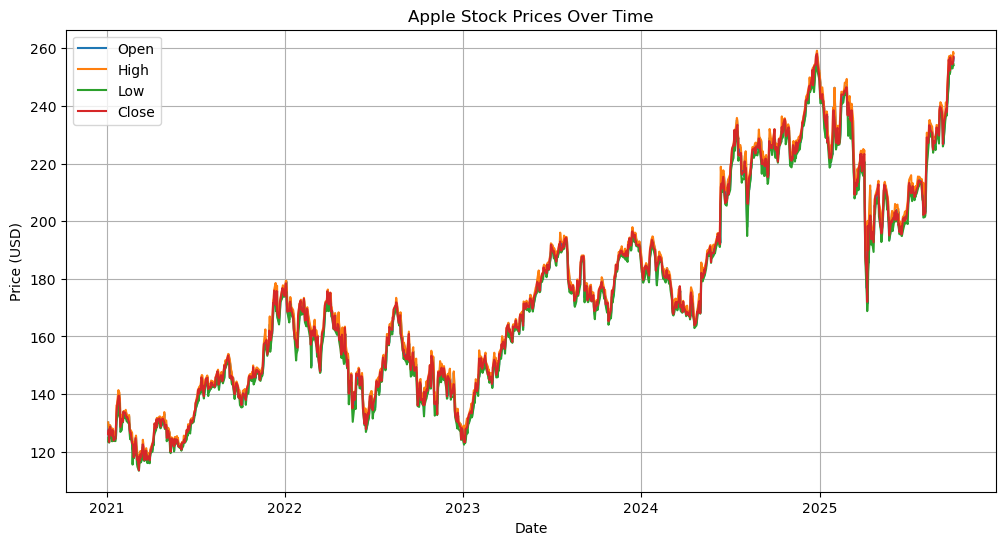

In [16]:
#to observe trend in price columns
import matplotlib.pyplot as plt


# List of price columns to plot
price_cols = ['Open', 'High', 'Low', 'Close']

plt.figure(figsize=(12,6))

# Loop over each column
for col in price_cols:
    plt.plot(df_pd['Date'], df_pd[col], label=col)

plt.legend()
plt.title("Apple Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()


From the figure, it can be seen that although there are fluctuations/variations, the plot shows an overall increasing trend in the stock price columns (Close, Low, High, Open) over the years from 2021 to 2025. All the price columns show similar behavior so we are going to choose 'Close' column for our analysis further. 

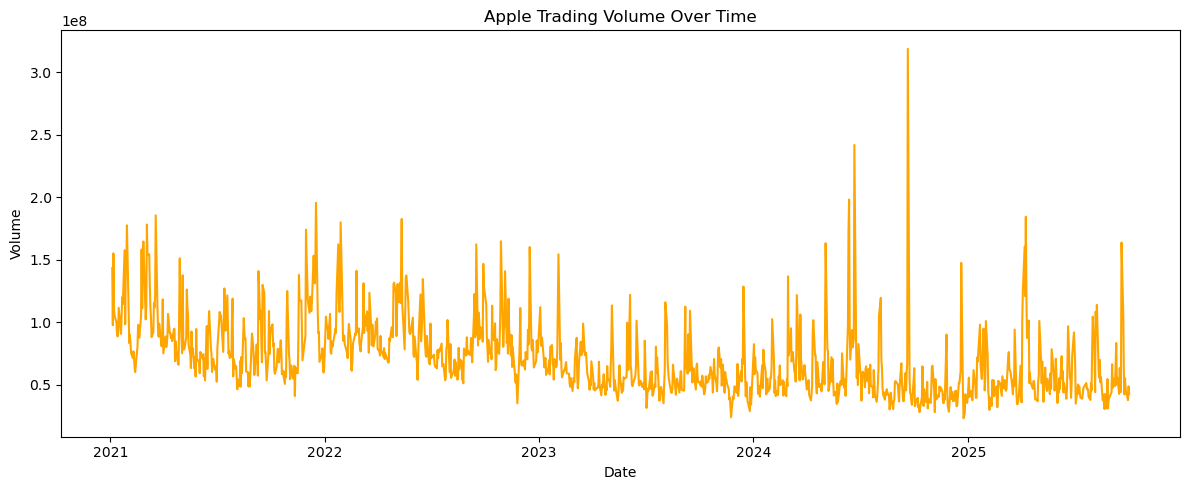

In [18]:
#to plot trading volume over time
plt.figure(figsize=(12,5))

plt.plot(df_pd['Date'], df_pd['Volume'], color='orange')
plt.title('Apple Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()


The graph shows high volatility. The volume rarely stays flat; it is characterized by frequent, sharp spikes and drops, indicating that the number of shares traded day-to-day change drastically. Overall, the trading volume spikes dramatically above the typical range, suggesting major news events, earnings announcements, or other market-moving activities driving a massive amount of buying and selling:

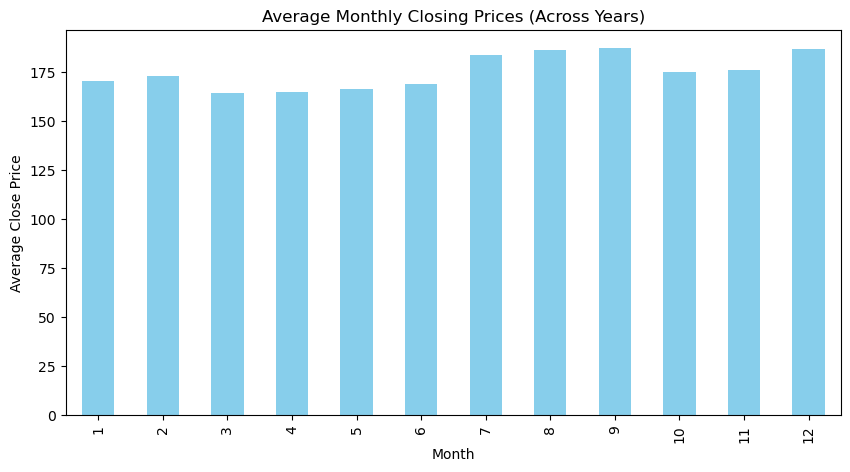

In [19]:
# 
df_pd['Date'] = pd.to_datetime(df_pd['Date'])
df_pd['Month'] = df_pd['Date'].dt.month
df_pd['Year'] = df_pd['Date'].dt.year

monthly_avg = df_pd.groupby('Month')['Close'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar', color='skyblue')
plt.title('Average Monthly Closing Prices (Across Years)')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.show()


The graph shows the average monthly closing price over the four years from 2021-2025. It can be seen that highest prices are observed in August, September and December over the years. It indicates that, on average, Apple’s stock tends to trade at higher prices during these months as compared to other months i.e.these months show historical seasonal strength.
Overall, this plot shows seasonal trends and these months likely reflect periods of strong investor sentiment linked to Apple’s product launches and year-end sales momentum.

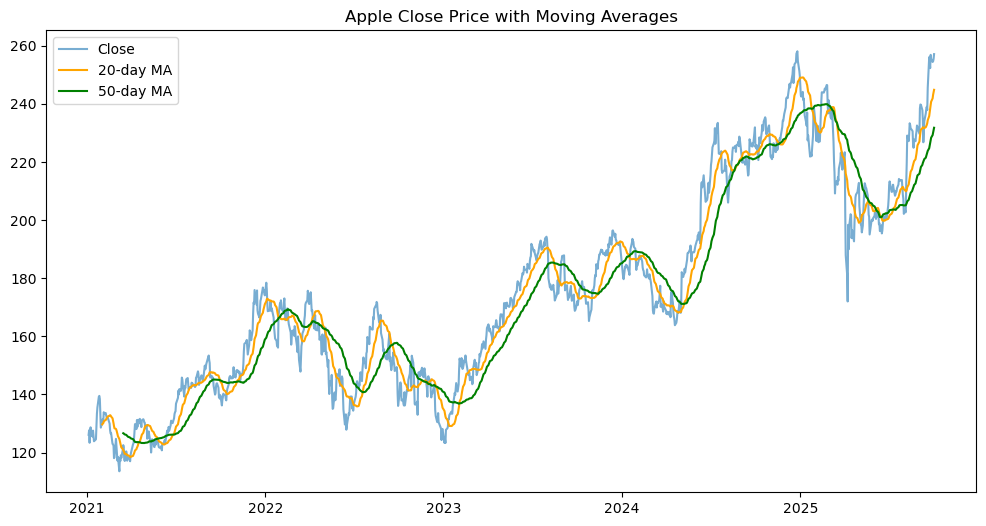

In [42]:
#to visulize trends by filtering out noise and smoothing the prices via averaging

df_pd['MA_20'] = df_pd['Close'].rolling(window=20).mean()
df_pd['MA_50'] = df_pd['Close'].rolling(window=50).mean()

plt.figure(figsize=(12,6))
plt.plot(df_pd['Date'], df_pd['Close'], label='Close', alpha=0.6)
plt.plot(df_pd['Date'], df_pd['MA_20'], label='20-day MA', color='orange')
plt.plot(df_pd['Date'], df_pd['MA_50'], label='50-day MA', color='green')
plt.title("Apple Close Price with Moving Averages")
plt.legend()
plt.show()


Moving averages are smoothed versions of the price that highlight trends, and plotting them with the actual closing price makes patterns and potential trading signals easier to see.
The above figure shows the original closing price with a lot of variations. The other two lines show the 20 day MA alongwith 50 day MA with considerably smoothed out versions of original price plot. They represent short term and medium term trends respectively. Overall, this smoothing helps to better visualize the trend in the closing price; which in our case shows it to be an increasing trend. 

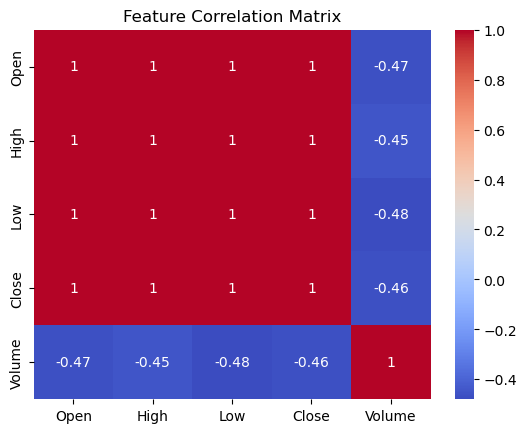

In [43]:
#to see the correlation among price columns and trading volume

df_pd[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
import seaborn as sns
sns.heatmap(df_pd[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


The correlation being 1 suggests that price columns are highly correlated i.e. when the stock price goes up or down, all these values tend to rise or fall together. Volume behaves inversely to price on average, showing that trading activity is often higher when prices are lower or As trading volume increases, the closing price tends to decrease somewhat.

Thus , in my dataset, the overall trend shows an inverse relationship between price levels and trading volume. Hence, all price features show negative correlation with volume.

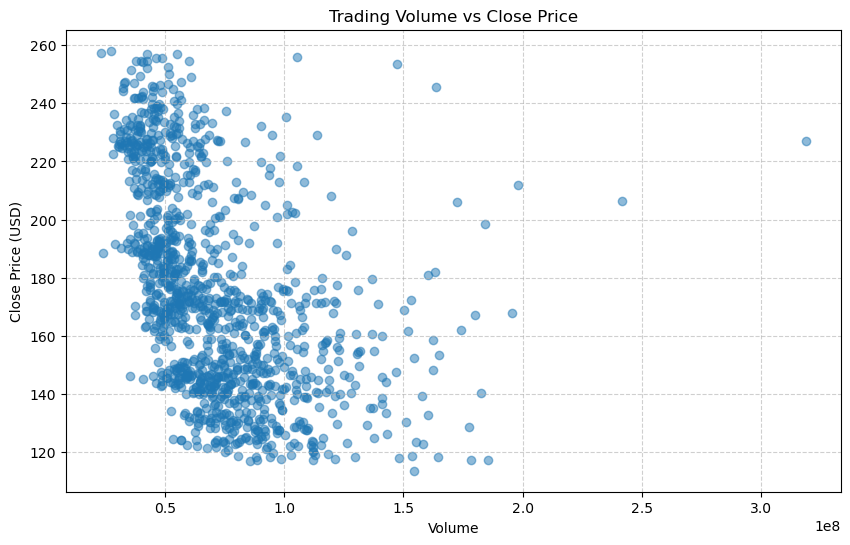

In [56]:
#to visualize scatter plot between trading volume and closing price
plt.figure(figsize=(10,6))
plt.scatter(df_pd['Volume'], df_pd['Close'], alpha=0.5)
plt.title('Trading Volume vs Close Price')
plt.xlabel('Volume')
plt.ylabel('Close Price (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


The figure shows a scatter plot to visualize the relationship between trading volume and closing price of Apple stock.
The scatter plot of Apple’s trading volume versus closing price shows that most trading days have relatively low to moderate volumes, with closing prices spread across a wide range up to around 240 dollars. A few days exhibit unusually high volumes, which often correspond to lower closing prices, likely reflecting market sell-offs or corrections. This visual pattern aligns with the calculated moderate negative correlation of -0.46, indicating that higher trading activity tends to coincide with lower stock prices, while typical trading days dominate the dataset.

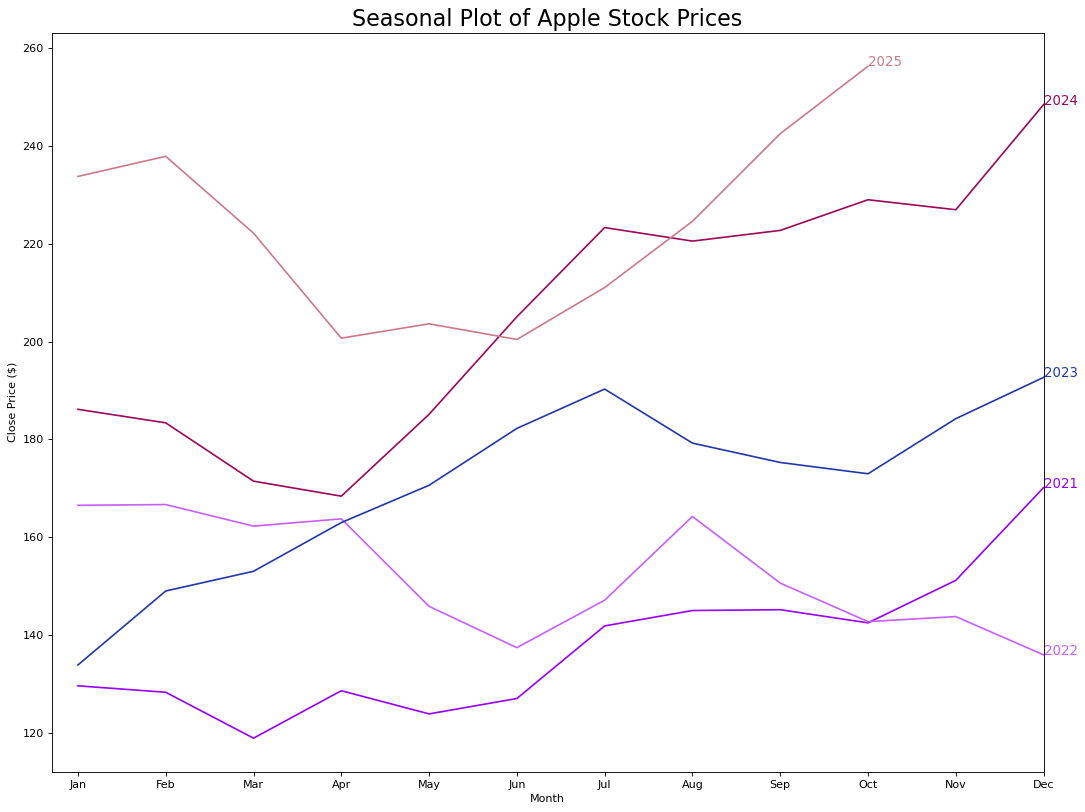

In [45]:
#to visualize and check seasonality

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


# Extract year and month number
df_pd['year'] = df_pd['Date'].dt.year
df_pd['month_num'] = df_pd['Date'].dt.month
df_pd['month'] = df_pd['Date'].dt.strftime('%b')  # Jan, Feb, ...
df_monthly = df_pd.groupby(['year', 'month_num', 'month'])['Close'].mean().reset_index()
years = df_monthly['year'].unique()
np.random.seed(100)
mycolors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(years), replace=False)

plt.figure(figsize=(16,12), dpi=80)

for i, y in enumerate(years):
    df_year = df_monthly[df_monthly['year'] == y]
    plt.plot(df_year['month_num']-1, df_year['Close'], color=mycolors[i], label=y)
    plt.text(df_year['month_num'].iloc[-1]-1, df_year['Close'].iloc[-1], str(y), fontsize=12, color=mycolors[i])

# Decoration
plt.xticks(ticks=np.arange(0,12), labels=df_monthly['month'].unique())
plt.xlim(-0.3, 11)
plt.ylabel('Close Price ($)')
plt.xlabel('Month')
plt.title("Seasonal Plot of Apple Stock Prices", fontsize=20)
plt.show()



The fgiure shows clear and consistent year-over-year increase in the average price level.  
In the Spring/early Summer, prices tend to trend flat or even decline from February/March, sometimes through June in most years (especially noticeable in 2021, 2022, and 2025).However, there is a pronounced increase in the average price during the second half of the year, usually starting around July/August and continuing through December. This frequently coincides with the company's fall product announcements and holiday shopping season. In contrast to other years,the 2022 year experienced a noticeable downtrend in the first three quarters (Jan to Sep), with the stock losing value before making a slight recovery into the year's end. 

### Model Training : LSTM ,GRU, BiLSTM, BiGRU

In [ ]:
#code with validation n hyperparameter tuning

In [131]:
#Select the desired column 
data = df_pd['Close'].values
#choose timestep
timestep = 30  


In [132]:
# Train-test split
train_size = int(len(data) * 0.8)
train_data_raw = data[:train_size]
test_data_raw = data[train_size:]

# Scale the data using min-max scaler
scaler = MinMaxScaler(feature_range=(0,1))
train_data_scaled = scaler.fit_transform(train_data_raw.reshape(-1,1))
test_data_scaled = scaler.transform(test_data_raw.reshape(-1,1))
#here reshaping is done to convert our 1D array into a 2D column vector

Min-Max scaling ensures all features are on the same scale (0–1), improving model performance and convergence.
When preprocessing, we fit the scaler only on the training data and then apply the same transformation to validation/test data to avoid data leakage nd to simulate realistic unseen data during testing.

In [133]:
val_size = int(len(train_data_scaled) * 0.1)
train_data_final = train_data_scaled[:-val_size]
val_data = train_data_scaled[-val_size:]
#Splits the scaled training data into 90% for training the model and 10% for validating the model during training. This helps monitor model performance and avoid overfitting.

In [134]:
# Sequence creation
def create_sequences(data, time_step):
    X, Y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        Y.append(data[i+time_step])
    return np.array(X), np.array(Y)

X_train_1, Y_train = create_sequences(train_data_final, timestep)
X_val_1, Y_val = create_sequences(val_data, timestep)
X_test_1, Y_test = create_sequences(test_data_scaled, timestep)
#Converts a 1D time series into sequences suitable for supervised learning so that the model can learn patterns over time_step past values to predict the next value.

# Reshape for LSTM/GRU input
X_train = X_train_1.reshape(X_train_1.shape[0], X_train_1.shape[1], 1)
X_val = X_val_1.reshape(X_val_1.shape[0], X_val_1.shape[1], 1)
X_test = X_test_1.reshape(X_test_1.shape[0], X_test_1.shape[1], 1)

The above reshape is done in order to prepare our time series sequences in the proper 3D format so that LSTM or GRU can process the sequential data correctly. This is because LSTM and GRU in Keras/PyTorch expect input of shape: (samples, timesteps, features).

samples → number of sequences (rows);
timesteps → number of past time steps in each sequence;
features → number of features per timestep (1 in your case, since it’s just the closing price).

### Pytorch Tensors

In [135]:
# Convertnumpy arrays to pytorch tensors
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).float()
X_val_tensor = torch.from_numpy(X_val).float()
Y_val_tensor = torch.from_numpy(Y_val).float()
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).float()

PyTorch models (like LSTM/GRU) cannot work directly with NumPy arrays. They need data in the form of tensors (multi-dimensional arrays similar to NumPy arrays but optimized for GPU computation).

In [136]:
# Dataloaders for batch processing
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_tensor, Y_train_tensor), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val_tensor, Y_val_tensor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, Y_test_tensor), batch_size=batch_size, shuffle=False)


The DataLoader objects in PyTorch are used to efficiently feed the LSTM/GRU model with batches of data during training, validation, and testing. Each TensorDataset combines the input sequences (X) and their corresponding targets (Y) into a single dataset, and the DataLoader splits it into batches of size 32. Setting shuffle=False preserves the temporal order of the time series, which is essential for sequential models.

In [ ]:
#Defining Models: LSTM, GRU, BiLSTM, BiGRU

In [140]:
import torch
import torch.nn as nn

# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.0):
        super(LSTMModel, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                           batch_first=True, dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout) if num_layers==1 else nn.Identity()
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])  #apply manual dropout if there is a single layer
        out = self.fc(out)
        return out


# BiLSTM Model-
class BiLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.0):
        super(BiLSTMModel, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                           batch_first=True, bidirectional=True,
                           dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout) if num_layers==1 else nn.Identity()
        self.fc = nn.Linear(hidden_size*2, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])   #apply manual dropout if there is a single layer
        out = self.fc(out)
        return out


# GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.0):
        super(GRUModel, self).__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers=num_layers, 
                          batch_first=True, dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout) if num_layers==1 else nn.Identity()
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])   #apply manual dropout if there is a single layer
        out = self.fc(out)
        return out


# BiGRU Model
class BiGRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.0):
        super(BiGRUModel, self).__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers=num_layers, 
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout) if num_layers==1 else nn.Identity()
        self.fc = nn.Linear(hidden_size*2, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])   #apply manual dropout if there is a single layer
        out = self.fc(out)
        return out


Each model accepts sequences with input_size =1 i.e. one features per timestep (closing price). It then processes them through one or more hidden layers with hidden_size units (number of neurons in the model's hidden state.). 
The num_layers parameter controls the depth of the recurrent network, and dropout is applied either manually for single-layer networks or internally in multi-layer networks to prevent overfitting.
For bidirectional models (BiLSTM and BiGRU), the recurrent layers process the input sequence in both forward and backward directions (we use hdden size *2 later), effectively doubling the hidden dimension fed to the final fully connected (Linear) layer. 
The forward method extracts the output of the last timestep, applies dropout if needed, and passes it through a linear layer to produce a single prediction for the next value in the sequence.

In [ ]:
#Hyperparameter tuning 

In [141]:
#This defines a grid of hyperparameters for tuning the RNN models
param_grid = {
    "hidden_size": [32, 50],
    "dropout": [0.1, 0.2],
    "num_layers": [1, 2]
}

Tuning parameters are: hidden size, dropout rate and no of layers. During grid search, the training process tries all possible combinations of these values to find the best-performing model.
Learning rate, timesteps, and batch size are not included in this tuning because they greatly increase the number of experiments and my VM has limited RAM and computation power, so tuning these would take too long.

In [142]:
#model dictionary
models_dict = {
    "LSTM": LSTMModel,
    "GRU": GRUModel,
    "BiLSTM": BiLSTMModel,  
    "BiGRU": BiGRUModel    
}
#This creates a Python dictionary that maps model names (strings) to their corresponding classes.

Note: The code below shows how to train all models together in a single loop and evaluate them to find their corresponding test and traiing metrics values. 
However, it takes more than hour to run the whoe loop for 4 models. My VM has limited RAM and computation power, so traiing these would take too long.To avoid this, I have broken the code and I am running the models separately. This is not efficient in terms of code writing but saves computation power and time for me. 

In [ ]:
#code using loop : donot run

In [ ]:
#code using separate sections for each model i.e. writing without for loop: start run

### Training 

In [143]:
#training the models

def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val_loss = float('inf')
    best_model = None
    
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    model.load_state_dict(best_model)
    return model, train_losses, val_losses


### Evaluation

In [144]:
#evaluating the models

def evaluate_model(model, loader):
    model.eval()
    preds = []
    y_true_list = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds.append(model(X_batch).detach().numpy())
            y_true_list.append(y_batch.numpy())
    preds = np.vstack(preds)
    y_true = np.vstack(y_true_list)
    preds_rescaled = scaler.inverse_transform(preds)
    y_true_rescaled = scaler.inverse_transform(y_true)
    
    rmse = np.sqrt(mean_squared_error(y_true_rescaled, preds_rescaled))
    mae = mean_absolute_error(y_true_rescaled, preds_rescaled)
    r2 = r2_score(y_true_rescaled, preds_rescaled)
    
    return rmse, mae, r2, preds_rescaled, y_true_rescaled

### LSTM

In [108]:
# Select the model 

model_name = "LSTM"
model_class = models_dict[model_name]

best_val_rmse = float('inf')
best_model = None
best_params = None


# Hyperparameter search
for hidden_size in param_grid["hidden_size"]:
    for dropout in param_grid["dropout"]:
        for num_layers in param_grid["num_layers"]:
            print(f"Trying hidden_size={hidden_size}, dropout={dropout}, num_layers={num_layers}")

            #Instantiate model
            model = model_class(hidden_size=hidden_size, dropout=dropout, num_layers=num_layers)
            #model = train_model(model, train_loader, val_loader, epochs=30, lr=0.001)
            #val_rmse, _, _, _, _ = evaluate_model(model, val_loader)

            #Train model (returns model, train_losses, val_losses)
            model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=30, lr=0.001)

            # Evaluate on validation set
            val_rmse, _, _, _, _ = evaluate_model(model, val_loader)

            # Save best model
            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_model = model
                best_params = (hidden_size, dropout, num_layers)

# Evaluate on train and test sets
train_rmse, train_mae, train_r2, _, _ = evaluate_model(best_model, train_loader)
test_rmse, test_mae, test_r2, _, _ = evaluate_model(best_model, test_loader)

results = {
    "params": best_params,
    "train_rmse": train_rmse,
    "train_mae": train_mae,
    "train_r2": train_r2,
    "test_rmse": test_rmse,
    "test_mae": test_mae,
    "test_r2": test_r2
}

print(f"\n=== {model_name} Results ===")
print(f"Best Params: {best_params}")
print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")


Trying hidden_size=32, dropout=0.1, num_layers=1
Epoch 1/30 | Train Loss: 0.143208 | Val Loss: 0.421133
Epoch 2/30 | Train Loss: 0.011574 | Val Loss: 0.073454
Epoch 3/30 | Train Loss: 0.028505 | Val Loss: 0.133457
Epoch 4/30 | Train Loss: 0.018208 | Val Loss: 0.079353
Epoch 5/30 | Train Loss: 0.016925 | Val Loss: 0.053773
Epoch 6/30 | Train Loss: 0.014825 | Val Loss: 0.024153
Epoch 7/30 | Train Loss: 0.012831 | Val Loss: 0.003500
Epoch 8/30 | Train Loss: 0.010581 | Val Loss: 0.004386
Epoch 9/30 | Train Loss: 0.008933 | Val Loss: 0.015601
Epoch 10/30 | Train Loss: 0.005618 | Val Loss: 0.018666
Epoch 11/30 | Train Loss: 0.003902 | Val Loss: 0.007996
Epoch 12/30 | Train Loss: 0.003527 | Val Loss: 0.001882
Epoch 13/30 | Train Loss: 0.003823 | Val Loss: 0.001364
Epoch 14/30 | Train Loss: 0.003639 | Val Loss: 0.001231
Epoch 15/30 | Train Loss: 0.003729 | Val Loss: 0.001239
Epoch 16/30 | Train Loss: 0.003923 | Val Loss: 0.001234
Epoch 17/30 | Train Loss: 0.003306 | Val Loss: 0.001254
Epoch 18

Epoch 24/30 | Train Loss: 0.002352 | Val Loss: 0.001090
Epoch 25/30 | Train Loss: 0.002374 | Val Loss: 0.001080
Epoch 26/30 | Train Loss: 0.002267 | Val Loss: 0.001095
Epoch 27/30 | Train Loss: 0.002146 | Val Loss: 0.001133
Epoch 28/30 | Train Loss: 0.002213 | Val Loss: 0.001087
Epoch 29/30 | Train Loss: 0.002270 | Val Loss: 0.001137
Epoch 30/30 | Train Loss: 0.002377 | Val Loss: 0.001346
Trying hidden_size=50, dropout=0.1, num_layers=2
Epoch 1/30 | Train Loss: 0.023601 | Val Loss: 0.045459
Epoch 2/30 | Train Loss: 0.063293 | Val Loss: 0.352179
Epoch 3/30 | Train Loss: 0.019502 | Val Loss: 0.144376
Epoch 4/30 | Train Loss: 0.030279 | Val Loss: 0.125329
Epoch 5/30 | Train Loss: 0.017199 | Val Loss: 0.109539
Epoch 6/30 | Train Loss: 0.013813 | Val Loss: 0.077164
Epoch 7/30 | Train Loss: 0.006350 | Val Loss: 0.030787
Epoch 8/30 | Train Loss: 0.003466 | Val Loss: 0.001631
Epoch 9/30 | Train Loss: 0.002573 | Val Loss: 0.001835
Epoch 10/30 | Train Loss: 0.002407 | Val Loss: 0.002486
Epoch 11

In [ ]:
#plotting training and validation loss

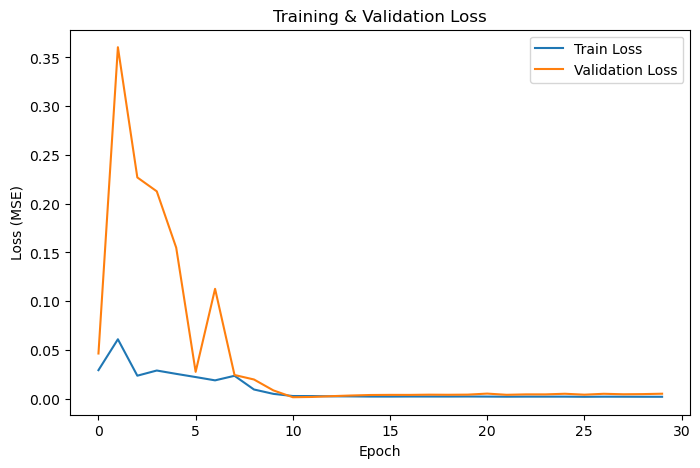

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title(f'{model_name} Training & Validation Loss')
plt.legend()
plt.show()


In [ ]:
# Plotting actual vs predicted values

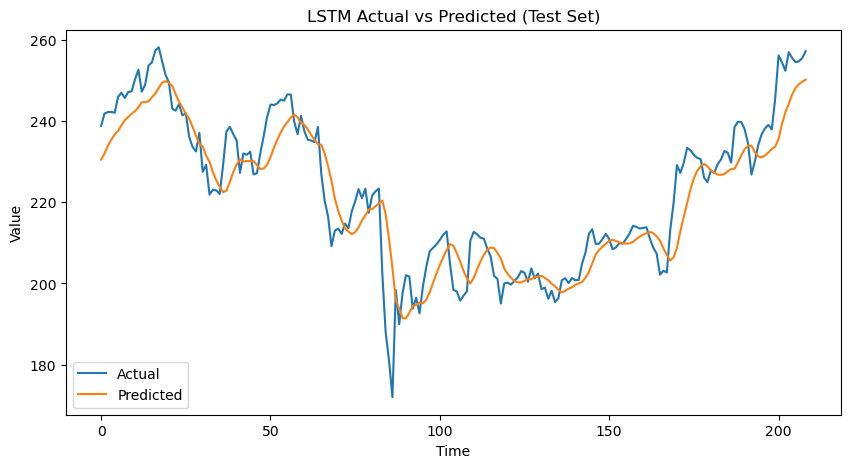

In [111]:

# Get predictions for test set
_, _, _, preds_rescaled, y_true_rescaled = evaluate_model(best_model, test_loader)

plt.figure(figsize=(10,5))
plt.plot(y_true_rescaled, label='Actual')
plt.plot(preds_rescaled, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'{model_name} Actual vs Predicted (Test Set)')
plt.legend()
plt.show()


### GRU

Trying hidden_size=32, dropout=0.1, num_layers=1
Epoch 1/30 | Train Loss: 0.046603 | Val Loss: 0.311606
Epoch 2/30 | Train Loss: 0.029960 | Val Loss: 0.236405
Epoch 3/30 | Train Loss: 0.027552 | Val Loss: 0.210279
Epoch 4/30 | Train Loss: 0.021974 | Val Loss: 0.156050
Epoch 5/30 | Train Loss: 0.017916 | Val Loss: 0.093239
Epoch 6/30 | Train Loss: 0.011389 | Val Loss: 0.014284
Epoch 7/30 | Train Loss: 0.005713 | Val Loss: 0.003070
Epoch 8/30 | Train Loss: 0.002468 | Val Loss: 0.001578
Epoch 9/30 | Train Loss: 0.002199 | Val Loss: 0.001729
Epoch 10/30 | Train Loss: 0.002272 | Val Loss: 0.001181
Epoch 11/30 | Train Loss: 0.002031 | Val Loss: 0.002486
Epoch 12/30 | Train Loss: 0.001899 | Val Loss: 0.002453
Epoch 13/30 | Train Loss: 0.001898 | Val Loss: 0.003147
Epoch 14/30 | Train Loss: 0.001866 | Val Loss: 0.002477
Epoch 15/30 | Train Loss: 0.001788 | Val Loss: 0.002040
Epoch 16/30 | Train Loss: 0.001934 | Val Loss: 0.003320
Epoch 17/30 | Train Loss: 0.001936 | Val Loss: 0.002039
Epoch 18

Epoch 24/30 | Train Loss: 0.001379 | Val Loss: 0.002132
Epoch 25/30 | Train Loss: 0.001220 | Val Loss: 0.001913
Epoch 26/30 | Train Loss: 0.001247 | Val Loss: 0.001818
Epoch 27/30 | Train Loss: 0.001349 | Val Loss: 0.001403
Epoch 28/30 | Train Loss: 0.001283 | Val Loss: 0.002175
Epoch 29/30 | Train Loss: 0.001220 | Val Loss: 0.000933
Epoch 30/30 | Train Loss: 0.001219 | Val Loss: 0.003550
Trying hidden_size=50, dropout=0.1, num_layers=2
Epoch 1/30 | Train Loss: 0.031903 | Val Loss: 0.194192
Epoch 2/30 | Train Loss: 0.032682 | Val Loss: 0.124798
Epoch 3/30 | Train Loss: 0.023406 | Val Loss: 0.055240
Epoch 4/30 | Train Loss: 0.012884 | Val Loss: 0.001547
Epoch 5/30 | Train Loss: 0.006014 | Val Loss: 0.002257
Epoch 6/30 | Train Loss: 0.001981 | Val Loss: 0.002194
Epoch 7/30 | Train Loss: 0.001846 | Val Loss: 0.002571
Epoch 8/30 | Train Loss: 0.001419 | Val Loss: 0.002181
Epoch 9/30 | Train Loss: 0.001424 | Val Loss: 0.003307
Epoch 10/30 | Train Loss: 0.001324 | Val Loss: 0.002535
Epoch 11

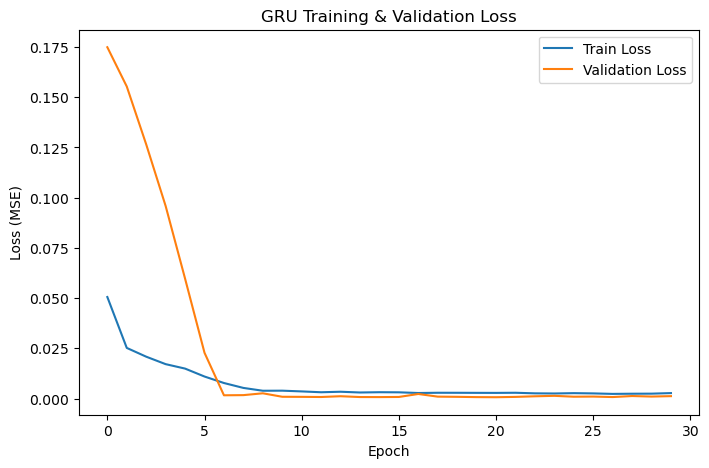

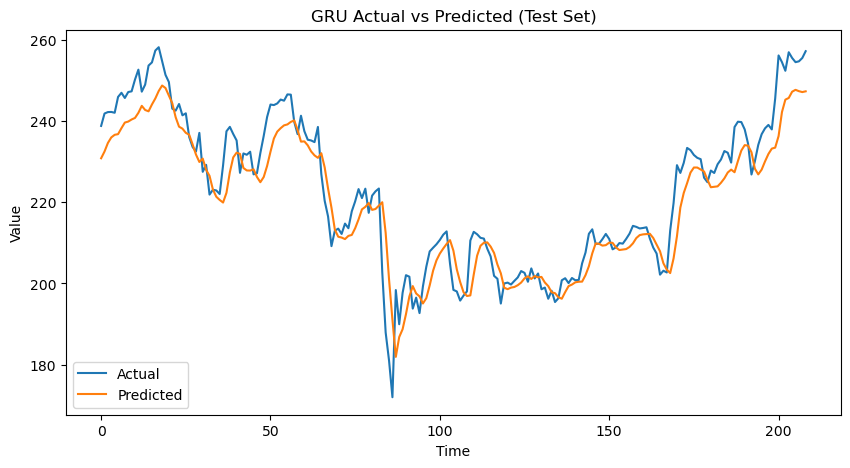

In [112]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


# Select the model and hyperparameter grid

model_name = "GRU"
model_class = models_dict[model_name]

best_val_rmse = float('inf')
best_model = None
best_params = None


final_train_losses = []
final_val_losses = []


# Hyperparameter search

for hidden_size in param_grid["hidden_size"]:
    for dropout in param_grid["dropout"]:
        for num_layers in param_grid["num_layers"]:
            print(f"Trying hidden_size={hidden_size}, dropout={dropout}, num_layers={num_layers}")
            
            # Instantiate model
            model = model_class(hidden_size=hidden_size, dropout=dropout, num_layers=num_layers)
            
            # Train model (returns model, train_losses, val_losses)
            model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=30, lr=0.001)
            
            # Evaluate on validation set
            val_rmse, _, _, _, _ = evaluate_model(model, val_loader)
            
            # Save best model
            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_model = model
                best_params = (hidden_size, dropout, num_layers)
                final_train_losses = train_losses
                final_val_losses = val_losses


# Evaluate on train and test sets
train_rmse, train_mae, train_r2, _, _ = evaluate_model(best_model, train_loader)
test_rmse, test_mae, test_r2, preds_rescaled, y_true_rescaled = evaluate_model(best_model, test_loader)

results = {
    "params": best_params,
    "train_rmse": train_rmse,
    "train_mae": train_mae,
    "train_r2": train_r2,
    "test_rmse": test_rmse,
    "test_mae": test_mae,
    "test_r2": test_r2
}

print(f"\n=== {model_name} Results ===")
print(f"Best Params: {best_params}")
print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")


# Plot training & validation loss
#plt.figure(figsize=(8,5))
#plt.plot(final_train_losses, label='Train Loss')
#plt.plot(final_val_losses, label='Validation Loss')
#plt.xlabel('Epoch')
#plt.ylabel('Loss (MSE)')
#plt.title(f'{model_name} Training & Validation Loss')
#plt.legend()
#plt.show()

# Plot actual vs predicted (test set)
#plt.figure(figsize=(10,5))
#plt.plot(y_true_rescaled, label='Actual')
#plt.plot(preds_rescaled, label='Predicted')
#plt.xlabel('Time')
#plt.ylabel('Value')
#plt.title(f'{model_name} Actual vs Predicted (Test Set)')
#plt.legend()
#plt.show()


In [ ]:
# Plot training & validation loss

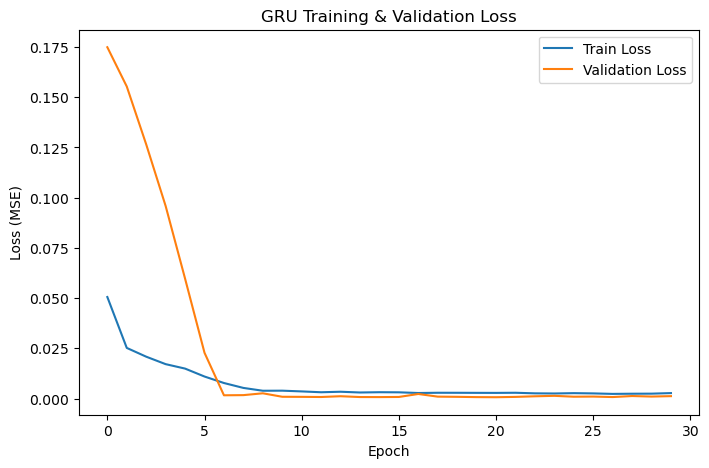

In [113]:

plt.figure(figsize=(8,5))
plt.plot(final_train_losses, label='Train Loss')
plt.plot(final_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title(f'{model_name} Training & Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Plotting actual vs predicted values

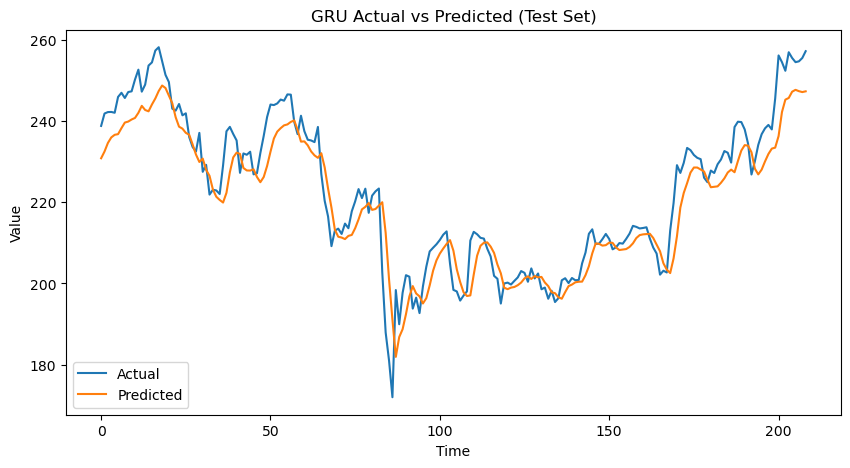

In [114]:

plt.figure(figsize=(10,5))
plt.plot(y_true_rescaled, label='Actual')
plt.plot(preds_rescaled, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'{model_name} Actual vs Predicted (Test Set)')
plt.legend()
plt.show()


### BiLSTM

Trying hidden_size=32, dropout=0.1, num_layers=1
Epoch 1/30 | Train Loss: 0.098874 | Val Loss: 0.345040
Epoch 2/30 | Train Loss: 0.019167 | Val Loss: 0.144684
Epoch 3/30 | Train Loss: 0.029590 | Val Loss: 0.171216
Epoch 4/30 | Train Loss: 0.019703 | Val Loss: 0.102459
Epoch 5/30 | Train Loss: 0.018765 | Val Loss: 0.062639
Epoch 6/30 | Train Loss: 0.014948 | Val Loss: 0.010002
Epoch 7/30 | Train Loss: 0.012694 | Val Loss: 0.006770
Epoch 8/30 | Train Loss: 0.012164 | Val Loss: 0.006841
Epoch 9/30 | Train Loss: 0.011226 | Val Loss: 0.001213
Epoch 10/30 | Train Loss: 0.005881 | Val Loss: 0.006610
Epoch 11/30 | Train Loss: 0.003389 | Val Loss: 0.002786
Epoch 12/30 | Train Loss: 0.003182 | Val Loss: 0.001107
Epoch 13/30 | Train Loss: 0.003134 | Val Loss: 0.001390
Epoch 14/30 | Train Loss: 0.002984 | Val Loss: 0.002023
Epoch 15/30 | Train Loss: 0.002743 | Val Loss: 0.001291
Epoch 16/30 | Train Loss: 0.002534 | Val Loss: 0.001147
Epoch 17/30 | Train Loss: 0.002709 | Val Loss: 0.001055
Epoch 18

Epoch 28/30 | Train Loss: 0.001541 | Val Loss: 0.003336
Epoch 29/30 | Train Loss: 0.001484 | Val Loss: 0.003407
Epoch 30/30 | Train Loss: 0.001472 | Val Loss: 0.002907
Trying hidden_size=50, dropout=0.1, num_layers=2
Epoch 1/30 | Train Loss: 0.022861 | Val Loss: 0.067218
Epoch 2/30 | Train Loss: 0.060505 | Val Loss: 0.339795
Epoch 3/30 | Train Loss: 0.021512 | Val Loss: 0.184554
Epoch 4/30 | Train Loss: 0.028914 | Val Loss: 0.167913
Epoch 5/30 | Train Loss: 0.019931 | Val Loss: 0.007036
Epoch 6/30 | Train Loss: 0.019339 | Val Loss: 0.018614
Epoch 7/30 | Train Loss: 0.020894 | Val Loss: 0.018908
Epoch 8/30 | Train Loss: 0.007647 | Val Loss: 0.009903
Epoch 9/30 | Train Loss: 0.003056 | Val Loss: 0.002430
Epoch 10/30 | Train Loss: 0.001873 | Val Loss: 0.001005
Epoch 11/30 | Train Loss: 0.001866 | Val Loss: 0.000958
Epoch 12/30 | Train Loss: 0.001628 | Val Loss: 0.001081
Epoch 13/30 | Train Loss: 0.001375 | Val Loss: 0.001630
Epoch 14/30 | Train Loss: 0.001261 | Val Loss: 0.002306
Epoch 15

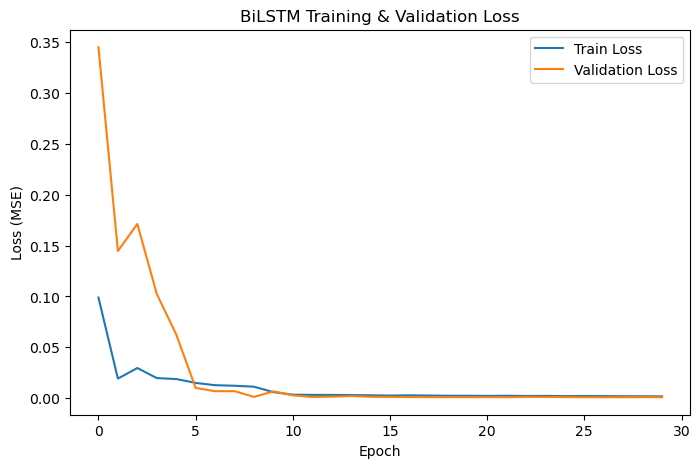

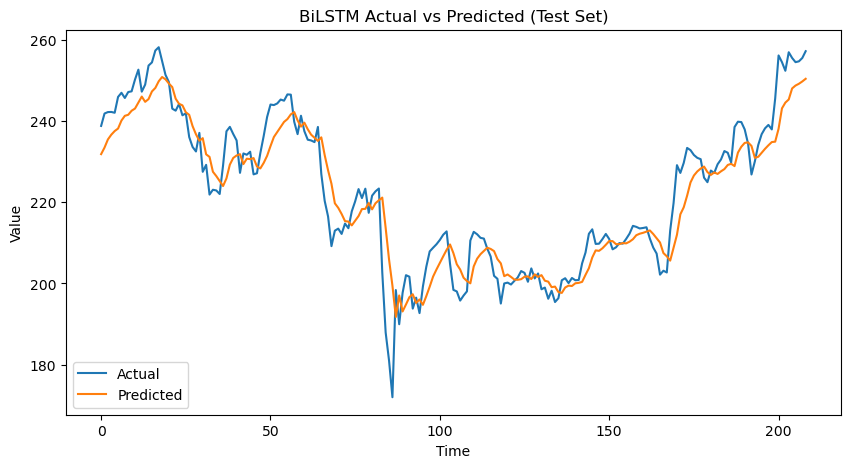

In [116]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


# Select the model and hyperparameter grid

model_name = "BiLSTM"
model_class = models_dict[model_name]

best_val_rmse = float('inf')
best_model = None
best_params = None

final_train_losses = []
final_val_losses = []

# Hyperparameter search

for hidden_size in param_grid["hidden_size"]:
    for dropout in param_grid["dropout"]:
        for num_layers in param_grid["num_layers"]:
            print(f"Trying hidden_size={hidden_size}, dropout={dropout}, num_layers={num_layers}")
            
            # Instantiate model
            model = model_class(hidden_size=hidden_size, dropout=dropout, num_layers=num_layers)
            
            # Train model (returns model, train_losses, val_losses)
            model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=30, lr=0.001)
            
            # Evaluate on validation set
            val_rmse, _, _, _, _ = evaluate_model(model, val_loader)
            
            # Save best model
            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_model = model
                best_params = (hidden_size, dropout, num_layers)
                final_train_losses = train_losses
                final_val_losses = val_losses


# Evaluate on train and test sets
train_rmse, train_mae, train_r2, _, _ = evaluate_model(best_model, train_loader)
test_rmse, test_mae, test_r2, preds_rescaled, y_true_rescaled = evaluate_model(best_model, test_loader)

results = {
    "params": best_params,
    "train_rmse": train_rmse,
    "train_mae": train_mae,
    "train_r2": train_r2,
    "test_rmse": test_rmse,
    "test_mae": test_mae,
    "test_r2": test_r2
}

print(f"\n=== {model_name} Results ===")
print(f"Best Params: {best_params}")
print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")

# Plot training & validation loss
#plt.figure(figsize=(8,5))
#plt.plot(final_train_losses, label='Train Loss')
#plt.plot(final_val_losses, label='Validation Loss')
#plt.xlabel('Epoch')
#plt.ylabel('Loss (MSE)')
#plt.title(f'{model_name} Training & Validation Loss')
#plt.legend()
#plt.show()

# Plot actual vs predicted (test set)
#plt.figure(figsize=(10,5))
#plt.plot(y_true_rescaled, label='Actual')
#plt.plot(preds_rescaled, label='Predicted')
#plt.xlabel('Time')
#plt.ylabel('Value')
#plt.title(f'{model_name} Actual vs Predicted (Test Set)')
#plt.legend()
#plt.show()


In [ ]:
# Plot training & validation loss

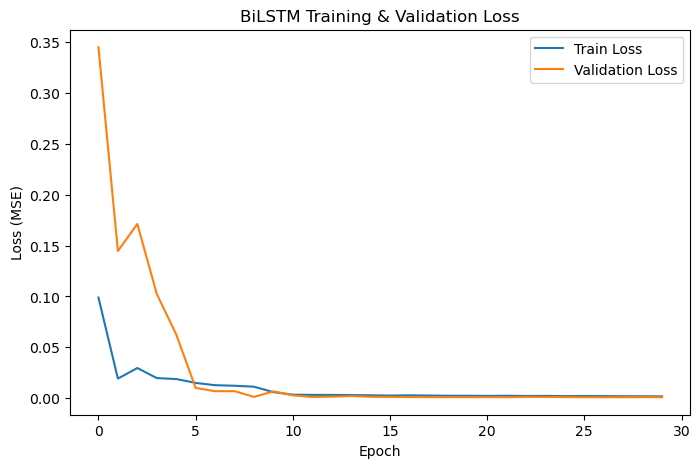

In [117]:

plt.figure(figsize=(8,5))
plt.plot(final_train_losses, label='Train Loss')
plt.plot(final_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title(f'{model_name} Training & Validation Loss')
plt.legend()
plt.show()




In [ ]:
# Plot actual vs predicted values

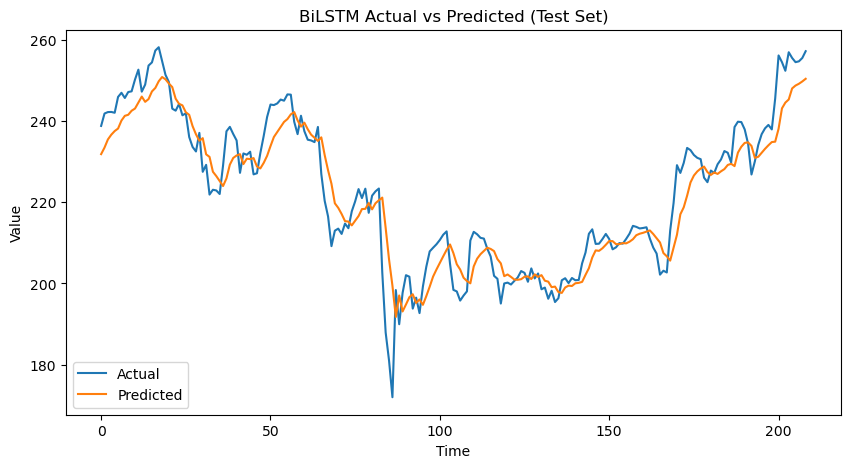

In [118]:

plt.figure(figsize=(10,5))
plt.plot(y_true_rescaled, label='Actual')
plt.plot(preds_rescaled, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'{model_name} Actual vs Predicted (Test Set)')
plt.legend()
plt.show()

### BiGRU

Trying hidden_size=32, dropout=0.1, num_layers=1
Epoch 1/30 | Train Loss: 0.030220 | Val Loss: 0.187798
Epoch 2/30 | Train Loss: 0.025742 | Val Loss: 0.171268
Epoch 3/30 | Train Loss: 0.020308 | Val Loss: 0.136868
Epoch 4/30 | Train Loss: 0.016183 | Val Loss: 0.087312
Epoch 5/30 | Train Loss: 0.011280 | Val Loss: 0.028638
Epoch 6/30 | Train Loss: 0.006223 | Val Loss: 0.002529
Epoch 7/30 | Train Loss: 0.002887 | Val Loss: 0.000852
Epoch 8/30 | Train Loss: 0.001710 | Val Loss: 0.001210
Epoch 9/30 | Train Loss: 0.001777 | Val Loss: 0.001083
Epoch 10/30 | Train Loss: 0.001663 | Val Loss: 0.001470
Epoch 11/30 | Train Loss: 0.001627 | Val Loss: 0.001693
Epoch 12/30 | Train Loss: 0.001740 | Val Loss: 0.001324
Epoch 13/30 | Train Loss: 0.001692 | Val Loss: 0.000979
Epoch 14/30 | Train Loss: 0.001548 | Val Loss: 0.001334
Epoch 15/30 | Train Loss: 0.001633 | Val Loss: 0.001467
Epoch 16/30 | Train Loss: 0.001457 | Val Loss: 0.001143
Epoch 17/30 | Train Loss: 0.001467 | Val Loss: 0.001430
Epoch 18

Epoch 24/30 | Train Loss: 0.001018 | Val Loss: 0.000785
Epoch 25/30 | Train Loss: 0.001064 | Val Loss: 0.000727
Epoch 26/30 | Train Loss: 0.001107 | Val Loss: 0.000848
Epoch 27/30 | Train Loss: 0.000985 | Val Loss: 0.000884
Epoch 28/30 | Train Loss: 0.000997 | Val Loss: 0.001005
Epoch 29/30 | Train Loss: 0.001019 | Val Loss: 0.000887
Epoch 30/30 | Train Loss: 0.000968 | Val Loss: 0.000782
Trying hidden_size=50, dropout=0.1, num_layers=2
Epoch 1/30 | Train Loss: 0.027421 | Val Loss: 0.160074
Epoch 2/30 | Train Loss: 0.029054 | Val Loss: 0.078263
Epoch 3/30 | Train Loss: 0.015165 | Val Loss: 0.003983
Epoch 4/30 | Train Loss: 0.005982 | Val Loss: 0.000899
Epoch 5/30 | Train Loss: 0.001358 | Val Loss: 0.001098
Epoch 6/30 | Train Loss: 0.001195 | Val Loss: 0.001196
Epoch 7/30 | Train Loss: 0.001029 | Val Loss: 0.001316
Epoch 8/30 | Train Loss: 0.001019 | Val Loss: 0.001857
Epoch 9/30 | Train Loss: 0.000977 | Val Loss: 0.001495
Epoch 10/30 | Train Loss: 0.000934 | Val Loss: 0.001567
Epoch 11

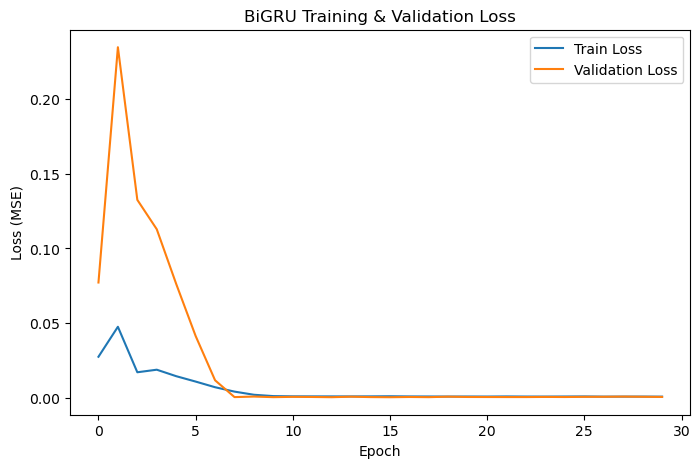

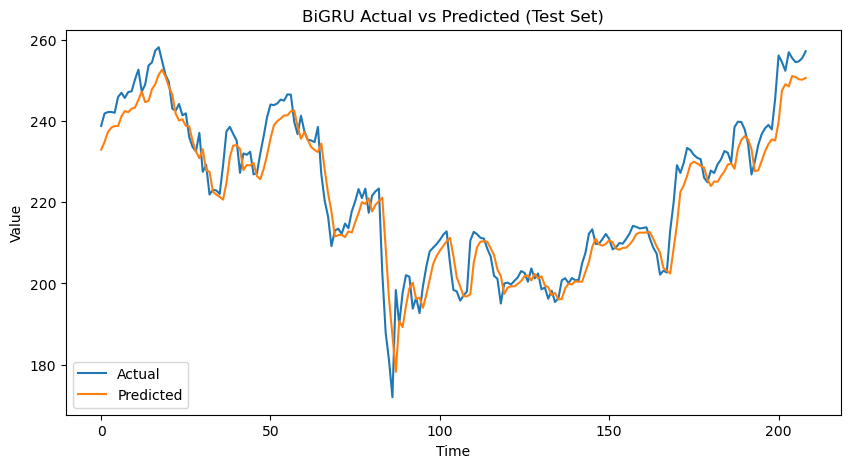

In [119]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Select the model and hyperparameter grid

model_name = "BiGRU"
model_class = models_dict[model_name]

best_val_rmse = float('inf')
best_model = None
best_params = None


final_train_losses = []
final_val_losses = []


# Hyperparameter search

for hidden_size in param_grid["hidden_size"]:
    for dropout in param_grid["dropout"]:
        for num_layers in param_grid["num_layers"]:
            print(f"Trying hidden_size={hidden_size}, dropout={dropout}, num_layers={num_layers}")
            
            # Instantiate model
            model = model_class(hidden_size=hidden_size, dropout=dropout, num_layers=num_layers)
            
            # Train model (returns model, train_losses, val_losses)
            model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=30, lr=0.001)
            
            # Evaluate on validation set
            val_rmse, _, _, _, _ = evaluate_model(model, val_loader)
            
            # Save best model
            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_model = model
                best_params = (hidden_size, dropout, num_layers)
                final_train_losses = train_losses
                final_val_losses = val_losses

# Evaluate on train and test sets
train_rmse, train_mae, train_r2, _, _ = evaluate_model(best_model, train_loader)
test_rmse, test_mae, test_r2, preds_rescaled, y_true_rescaled = evaluate_model(best_model, test_loader)

results = {
    "params": best_params,
    "train_rmse": train_rmse,
    "train_mae": train_mae,
    "train_r2": train_r2,
    "test_rmse": test_rmse,
    "test_mae": test_mae,
    "test_r2": test_r2
}

print(f"\n=== {model_name} Results ===")
print(f"Best Params: {best_params}")
print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8,5))
plt.plot(final_train_losses, label='Train Loss')
plt.plot(final_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title(f'{model_name} Training & Validation Loss')
plt.legend()
plt.show()

# Plot actual vs predicted (test set)
plt.figure(figsize=(10,5))
plt.plot(y_true_rescaled, label='Actual')
plt.plot(preds_rescaled, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'{model_name} Actual vs Predicted (Test Set)')
plt.legend()
plt.show()


In [ ]:
# Plot training & validation loss

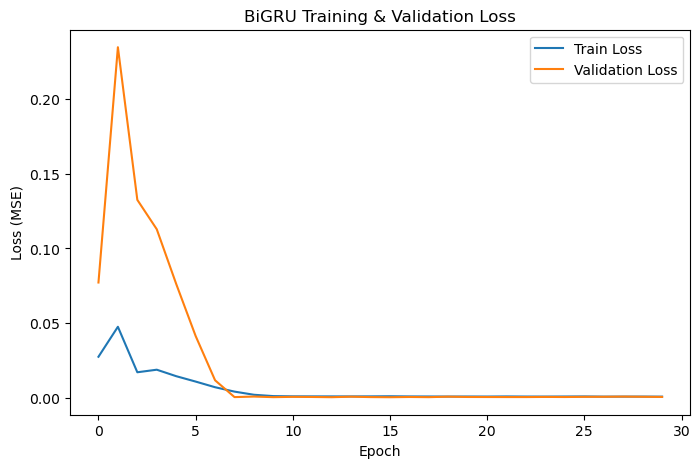

In [120]:

plt.figure(figsize=(8,5))
plt.plot(final_train_losses, label='Train Loss')
plt.plot(final_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title(f'{model_name} Training & Validation Loss')
plt.legend()
plt.show()



In [ ]:
# Plot actual vs predicted values

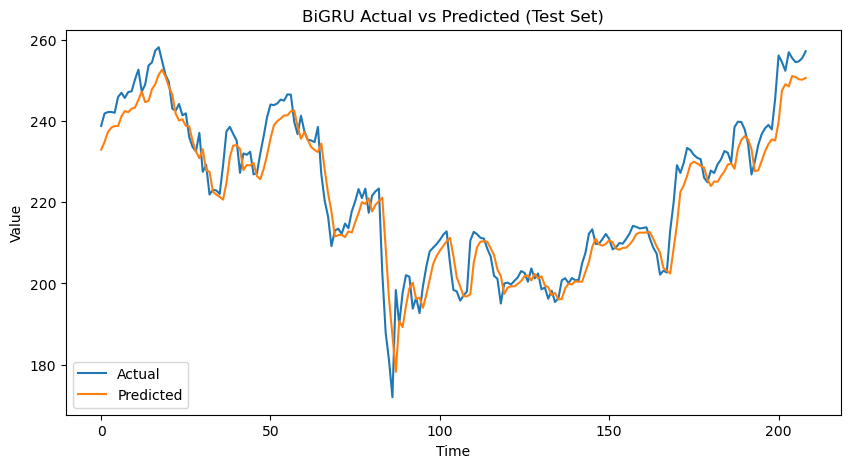

In [121]:

plt.figure(figsize=(10,5))
plt.plot(y_true_rescaled, label='Actual')
plt.plot(preds_rescaled, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'{model_name} Actual vs Predicted (Test Set)')
plt.legend()
plt.show()


### Conclusion

It can be seen from the table that all four recurrent neural network models: LSTM, GRU, BiLSTM, and BiGRU demonstrated strong predictive performance on the stock closing price dataset. The LSTM achieves a good fit to the training data and generalizes reasonably well to the test set, though there is a modest increase in error. The GRU slightly outperforms LSTM on test data (R² = 0.871), likely due to its more parameter-efficient gating mechanism, showing robust generalization with minimal overfitting.
The BiLSTM, leveraging bidirectional context, further improves predictive accuracy (R² = 0.877 on test data), demonstrating that capturing both past and future temporal dependencies enhances performance. Finally, the BiGRU achieves the best overall results, with the lowest prediction errors (Test RMSE = 5.55) and highest explanatory power (R² = 0.914), effectively learning complex temporal patterns while maintaining excellent generalization.
Across all models, the gap between training and test performance remains moderate, indicating good generalization without overfitting. Overall, the results highlight that bidirectional models outperform their unidirectional counterparts on the test set and BiGRU model achieves the best overall performance with the highest R² for time-series forecasting. This is because these models incorporate information from both past and future observations, making them highly suitable for financial trend prediction.


### Extra Code for big data part: comparison between spark dataframe and rdd processing times

In [3]:

#This part is separate from the rest of the assignment. It just shows the comparison of processing times using spark dataframe and RDD on a small portion of the code. This is done just to show some big data computing. 
#reading data
df = spark.read.csv("hdfs:///user1/Apple1.csv", header=True, inferSchema=True)

# Separate numeric and non-numeric columns
numeric_cols = [c[0] for c in df.dtypes if c[1] in ('int', 'double', 'float')]
non_numeric_cols = [c[0] for c in df.dtypes if c[1] not in ('int', 'double', 'float')]

# Count nulls for numeric columns (check for NaN as well)
numeric_nulls = df.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in numeric_cols])

# Count nulls for non-numeric columns (only check for NULL)
non_numeric_nulls = df.select([count(when(col(c).isNull(), c)).alias(c) for c in non_numeric_cols])

# Show results
print("Numeric column nulls:")
numeric_nulls.show()
print("Non-numeric column nulls:")
non_numeric_nulls.show()

#using spart dataframe to do some preprocessing
#importing time to come preprocessing itme
import time
# Relevant columns
columns = ["Date", "Close", "Open", "High", "Low", "Volume"]

# start timing
start_df = time.time()

df_clean = df.select(columns).na.drop()
df_clean = df_clean.withColumn("Date", to_date(col("Date")))
df_clean = df_clean.orderBy("Date")

# Compute additional features i.e. daily return and daily volatility
df_clean = df_clean.withColumn("daily_return", (col("Close") - col("Open")) / col("Open"))
df_clean = df_clean.withColumn("daily_volatility", (col("High") - col("Low")) / col("Open"))

# Convert to pandas 
df_pdd = df_clean.toPandas()

#end time
end_df = time.time()

print("DataFrame preprocessing time:", round(end_df - start_df, 4), "seconds")

df_pdd.head()

#using RDD to do some preprocessing
#start time
start_rdd = time.time()

# Select columns and drop nulls
rdd = df.select(columns).na.drop().rdd

# Map to proper types (Date is already in datetime format)
rdd_clean = rdd.map(lambda row: (
    row['Date'],           
    float(row['Open']),
    float(row['High']),
    float(row['Low']),
    float(row['Close']),
    float(row['Volume'])
))

# Sort by Date
rdd_clean = rdd_clean.sortBy(lambda x: x[0])

# Compute additional features i.e. daily returns and daily volatility
rdd_features = rdd_clean.map(lambda x: (
    x[0], x[1], x[2], x[3], x[4], x[5],
    (x[4] - x[1]) / x[1],  # daily_return
    (x[2] - x[3]) / x[1]   # daily_volatility
))

# Convert to Pandas
df_rdd = pd.DataFrame(
    rdd_features.collect(),
    columns=[
        "Date", "Open", "High", "Low", "Close", "Volume",
        "daily_return", "daily_volatility"
    ]
)

#end time
end_rdd = time.time()

print("RDD preprocessing time:", round(end_rdd - start_rdd, 4), "seconds")
#df_rdd.head()



Numeric column nulls:


+----+----+---+-----+------+---------+------------+
|Open|High|Low|Close|Volume|Dividends|Stock Splits|
+----+----+---+-----+------+---------+------------+
|   0|   0|  0|    0|     0|        0|           0|
+----+----+---+-----+------+---------+------------+

Non-numeric column nulls:
+----+
|Date|
+----+
|   0|
+----+



DataFrame preprocessing time: 3.3279 seconds


RDD preprocessing time: 2.5741 seconds


Observation: This chunk of code compares preprocessing times using spark dataframe and RDD. The results show that spark dataframe takes less time than RDD. The reason for this is that spark dataframes are faster than RDDs as they leverage catalyst query optimization, columnar memory storage, and built-in optimized functions, whereas RDDs are more low-level, row-based, and require explicit transformation code without internal optimization.
